In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv('Titanic-Dataset.csv')

In [3]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df.isnull().sum()/len(df)*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [10]:
df["Survived"].value_counts()
df["Survived"].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

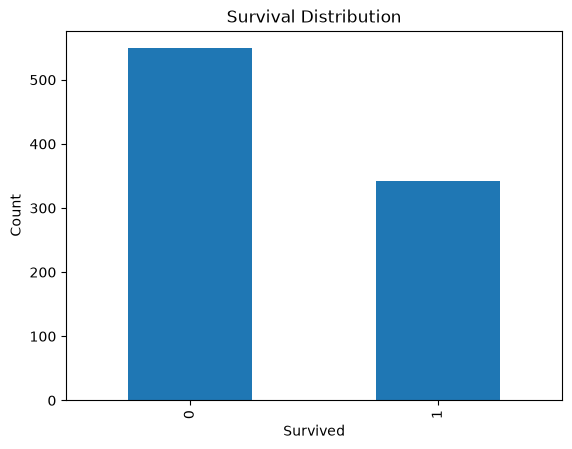

In [11]:
df["Survived"].value_counts().plot(kind="bar")

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

The target variable is moderately imbalanced, with more passengers not surviving than surviving. Although the imbalance is not severe, relying solely on accuracy may not provide a complete evaluation of model performance. Therefore, additional metrics such as Precision, Recall, F1-score, and the Confusion Matrix should also be considered.

<Axes: xlabel='Age', ylabel='Count'>

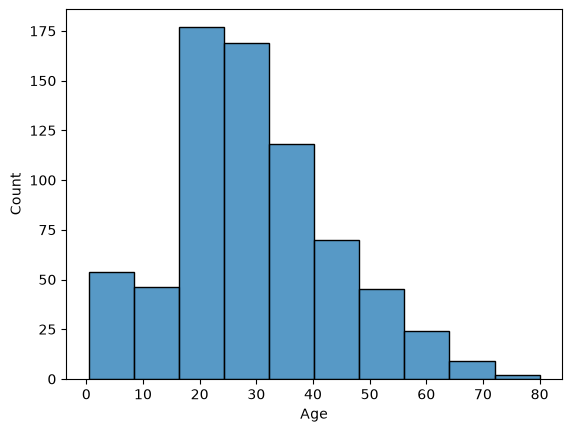

In [12]:
sns.histplot(df["Age"],bins=10)

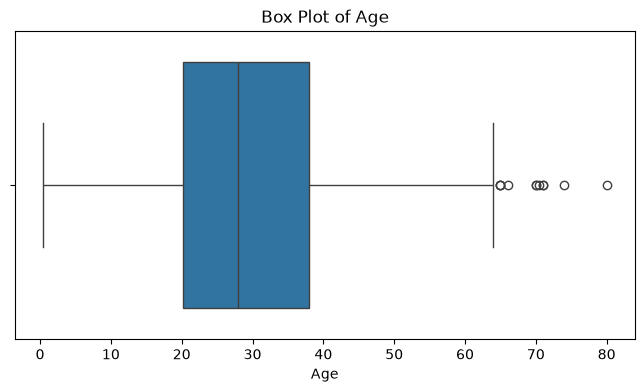

In [13]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Age"])
plt.title("Box Plot of Age")
plt.show()


The middle 50% of passengers are approximately between 20 and 38 years old.
The median age is around 28 years, suggesting that most passengers were relatively young adults.
There are a few passengers older than about 65 years, which are identified as outliers by the box plot.
These outliers appear to be plausible ages rather than obvious data errors, so they require further consideration before deciding whether any preprocessing is necessary.

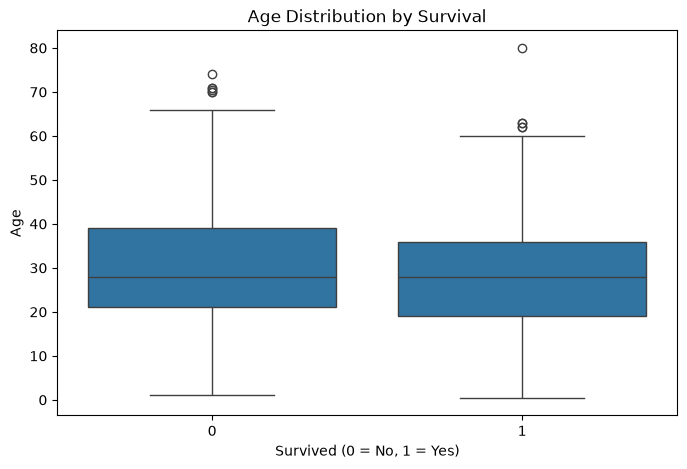

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Survived", y="Age", data=df)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

The median age of survivors and non-survivors appears to be similar. Both groups have comparable age distributions and contain elderly outliers. Based on this box plot alone, age does not seem to clearly distinguish between passengers who survived and those who did not. However, further analysis with other features is needed before drawing a final conclusion."

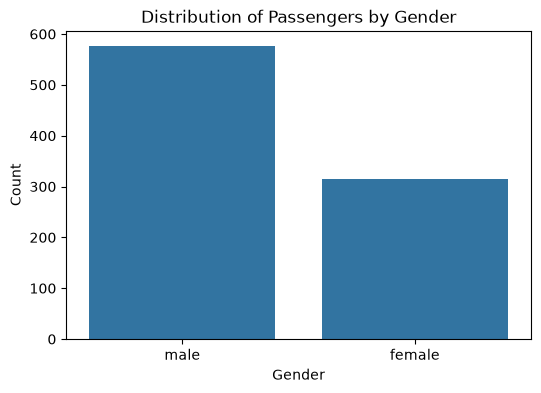

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sex", data=df)

plt.title("Distribution of Passengers by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

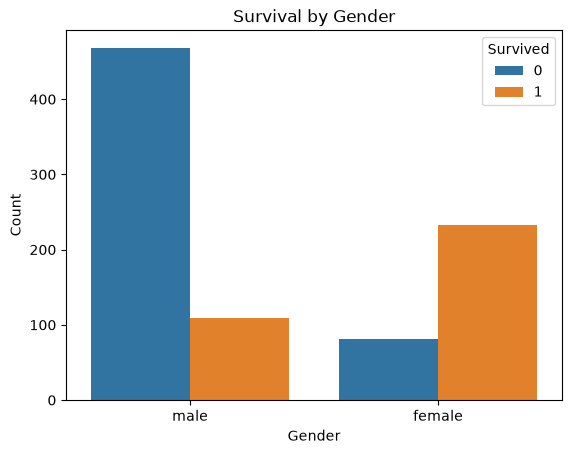

In [16]:
sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.legend(title="Survived")

plt.show()

Gender appears to have a strong relationship with survival. Female passengers had a significantly higher survival rate than male passengers. However, gender alone is not sufficient to perfectly predict survival because some males survived and some females did not. Therefore, Sex is likely to be an important feature for the prediction model

In [17]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

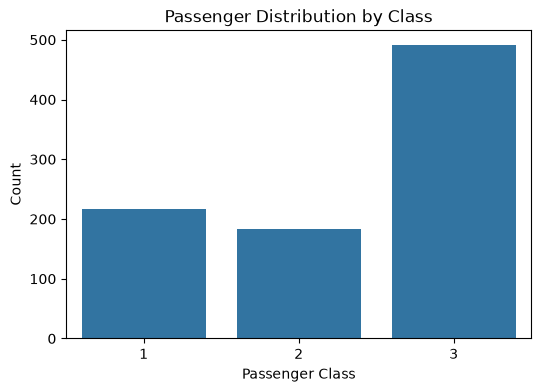

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x="Pclass", data=df)

plt.title("Passenger Distribution by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

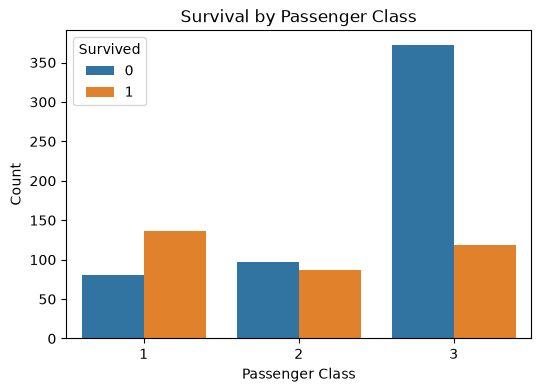

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.legend(title="Survived")

plt.show()

**Observations:**
- Third-class passengers were the largest group in the dataset.
- More first-class passengers survived than died.
- Second-class passengers had a more balanced survival distribution.
- Most third-class passengers did not survive.

**Possible Explanation:**
- Passenger class may have influenced access to lifeboats or evacuation routes, resulting in different survival outcomes.

**Conclusion:**
`Pclass` shows a strong association with passenger survival and is likely to be an important feature for prediction.

In [20]:
pd.crosstab(df["Pclass"], df["Survived"], normalize="index") * 100

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


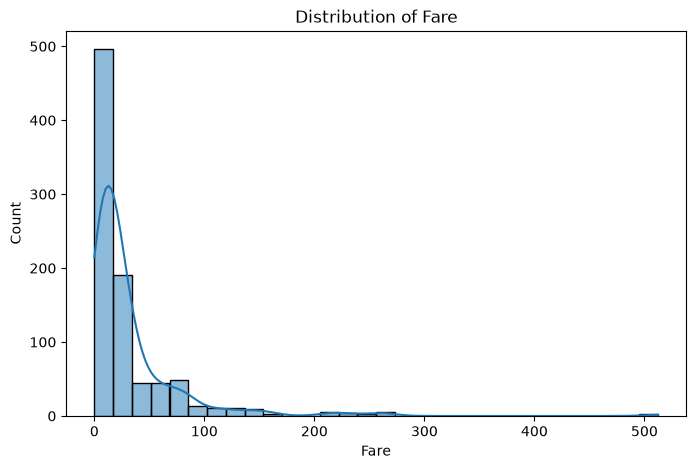

In [21]:
df["Fare"].describe()
plt.figure(figsize=(8,5))

sns.histplot(df["Fare"], bins=30, kde=True)

plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.show()

- Most passengers paid relatively low fares.
- Only a few passengers paid very high fares.
- The Fare distribution is positively (right) skewed.
- The long right tail suggests the presence of high-fare values that may act as outliers.


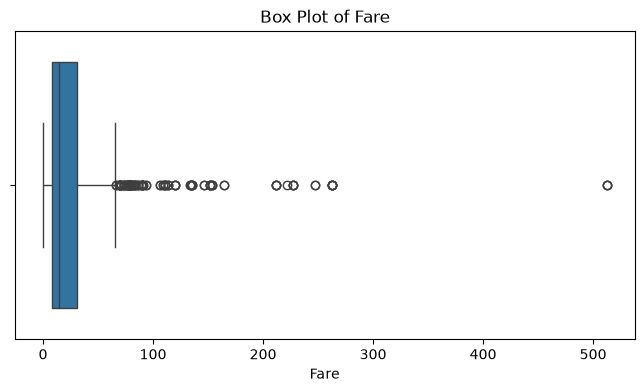

In [22]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Fare"])

plt.title("Box Plot of Fare")

plt.show()

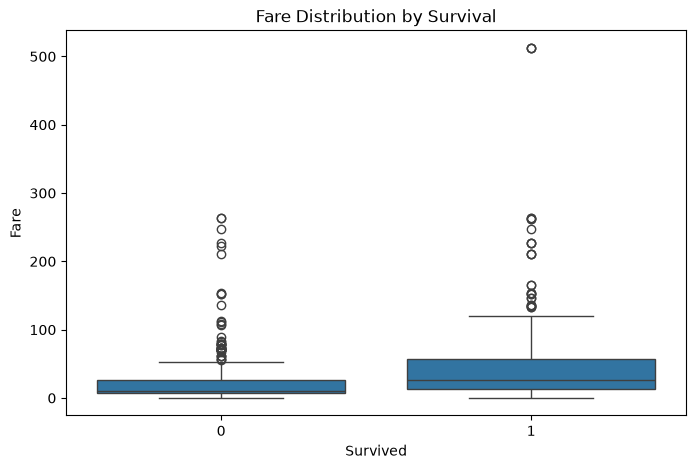

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Survived", y="Fare", data=df)

plt.title("Fare Distribution by Survival")

plt.xlabel("Survived")
plt.ylabel("Fare")

plt.show()

- The Fare distribution is highly right-skewed.
- Most passengers paid relatively low fares.
- Fare contains several high-value outliers.
- Survivors generally have higher ticket fares than non-survivors.
- The distributions overlap, indicating Fare alone cannot perfectly predict survival.

In [24]:
df["SibSp"].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

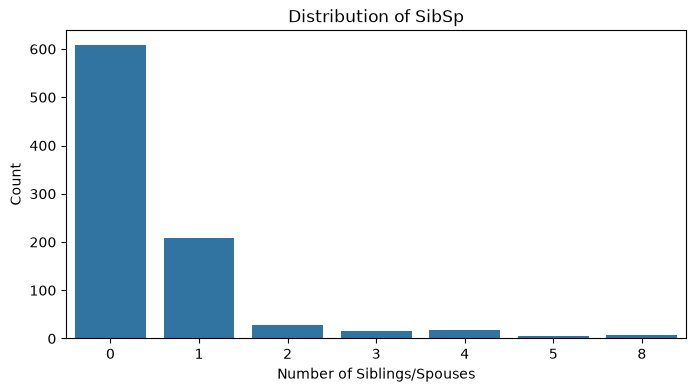

In [25]:
plt.figure(figsize=(8,4))

sns.countplot(x="SibSp", data=df)

plt.title("Distribution of SibSp")
plt.xlabel("Number of Siblings/Spouses")
plt.ylabel("Count")

plt.show()

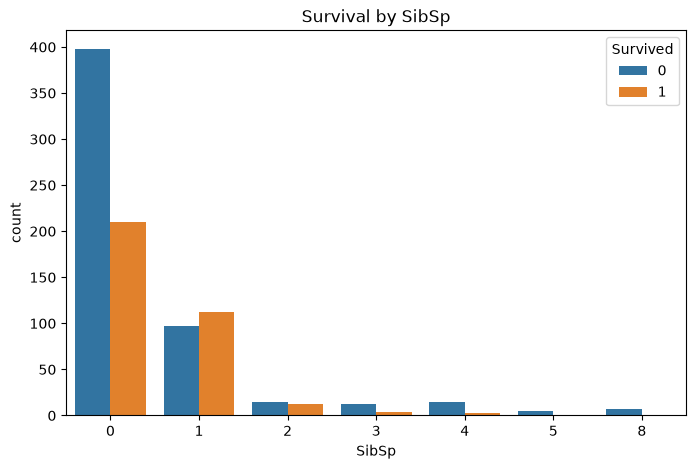

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(x="SibSp", hue="Survived", data=df)

plt.title("Survival by SibSp")

plt.show()

In [27]:
pd.crosstab(df["SibSp"], df["Survived"], normalize="index")*100

Survived,0,1
SibSp,,
0,65.460526,34.539474
1,46.411483,53.588517
2,53.571429,46.428571
3,75.000000,25.000000
4,83.333333,16.666667
5,100.000000,0.000000
8,100.000000,0.000000


In [28]:
df["Parch"].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

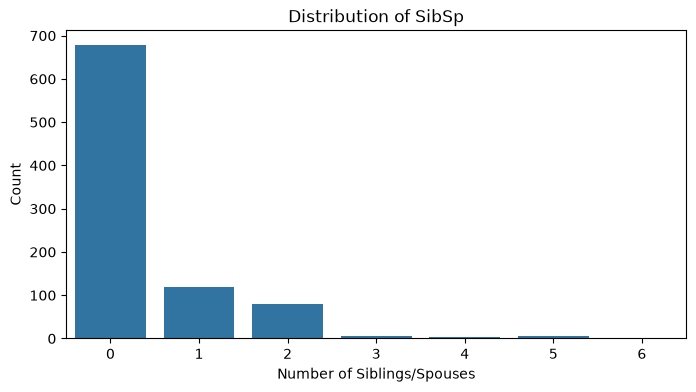

In [29]:
plt.figure(figsize=(8,4))

sns.countplot(x="Parch", data=df)

plt.title("Distribution of SibSp")
plt.xlabel("Number of Siblings/Spouses")
plt.ylabel("Count")

plt.show()

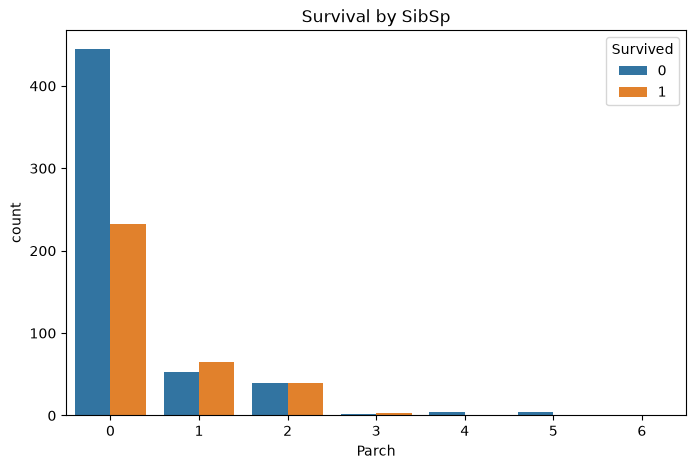

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(x="Parch", hue="Survived", data=df)

plt.title("Survival by SibSp")

plt.show()

In [31]:
pd.crosstab(df["Parch"], df["Survived"], normalize="index")*100

Survived,0,1
Parch,,
0,65.634218,34.365782
1,44.915254,55.084746
2,50.000000,50.000000
3,40.000000,60.000000
4,100.000000,0.000000
5,80.000000,20.000000
6,100.000000,0.000000


- Most passengers traveled without parents or children.
- Passengers traveling with one or two parents/children generally showed higher survival rates than those traveling alone.
- Very large parent/child groups had lower survival rates.
- Extreme values (e.g., Parch = 4 or 6) should be interpreted carefully because they may contain only a few passengers.

In [32]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [33]:
df["Embarked"].value_counts(normalize=True) * 100

Embarked
S    72.440945
C    18.897638
Q     8.661417
Name: proportion, dtype: float64

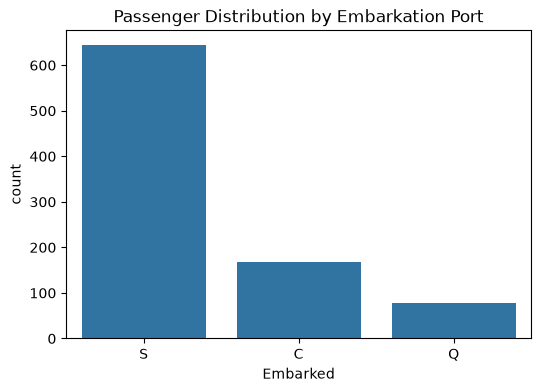

In [34]:
plt.figure(figsize=(6,4))

sns.countplot(x="Embarked", data=df)

plt.title("Passenger Distribution by Embarkation Port")

plt.show()

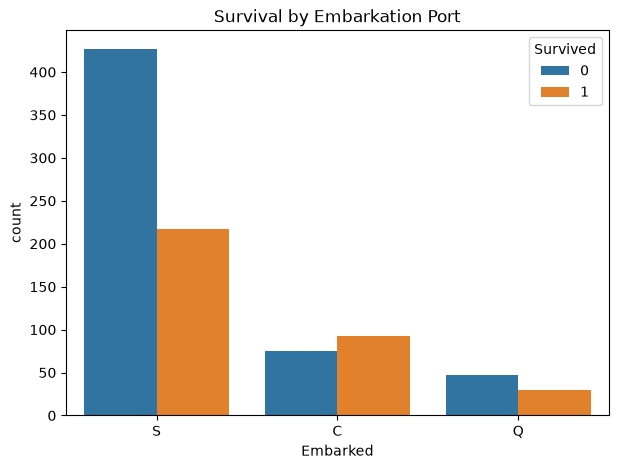

In [35]:
plt.figure(figsize=(7,5))

sns.countplot(x="Embarked", hue="Survived", data=df)

plt.title("Survival by Embarkation Port")

plt.show()

In [36]:
pd.crosstab(df["Embarked"], df["Survived"], normalize="index") * 100

Survived,0,1
Embarked,,
C,44.642857,55.357143
Q,61.038961,38.961039
S,66.304348,33.695652


In [37]:
df["Cabin"].isnull().sum()

np.int64(687)

In [38]:
df["Cabin"].isnull().mean()*100

np.float64(77.10437710437711)

In [39]:
df["Cabin"].head(20)

0      NaN
1      C85
2      NaN
3     C123
4      NaN
5      NaN
6      E46
7      NaN
8      NaN
9      NaN
10      G6
11    C103
12     NaN
13     NaN
14     NaN
15     NaN
16     NaN
17     NaN
18     NaN
19     NaN
Name: Cabin, dtype: str

In [40]:
df["Cabin"].str[0].value_counts(dropna=False)

Cabin
NaN    687
C       59
B       47
D       33
E       32
A       15
F       13
G        4
T        1
Name: count, dtype: int64

In [41]:
df["CabinAvailable"] = df["Cabin"].notnull()

In [42]:
cabin_survival=pd.crosstab(
    df["CabinAvailable"],
    df["Survived"],
    normalize="index"
) * 100
print(cabin_survival)

Survived                0          1
CabinAvailable                      
False           70.014556  29.985444
True            33.333333  66.666667


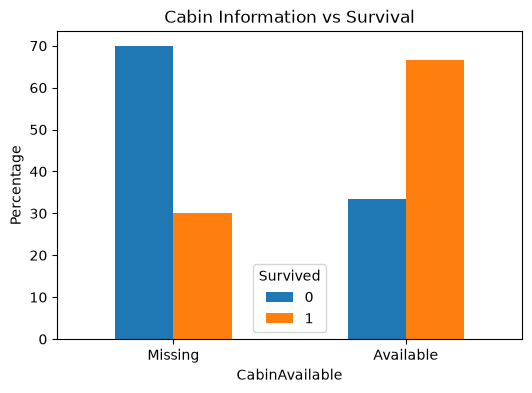

In [43]:
cabin_survival.plot(kind="bar", figsize=(6,4))
plt.ylabel("Percentage")
plt.title("Cabin Information vs Survival")
plt.xticks([0,1], ["Missing", "Available"], rotation=0)
plt.show()

The survival rate is more than double when cabin information is available.
### Investigation: Does Missing Cabin Information Matter?

A new feature called `CabinAvailable` was created:

- True → Cabin information is available.
- False → Cabin information is missing.

### Results

- Passengers with missing cabin information had a survival rate of approximately **30%**.
- Passengers with available cabin information had a survival rate of approximately **67%**.

### Key Insight

The missingness of the `Cabin` feature is not random. It appears to be associated with survival, meaning the absence of data itself carries useful information.

### Conclusion

Instead of dropping the `Cabin` feature solely because it contains many missing values, it should first be investigated. Feature engineering techniques such as extracting the deck or creating a `CabinAvailable` indicator may preserve valuable predictive information.

## Why didn't we drop the Cabin feature immediately?

Initially, the Cabin feature appeared to be a good candidate for removal because approximately 77% of its values were missing.

However, further investigation revealed several important insights:

- Cabin contains meaningful information such as the passenger's deck.
- The deck can be extracted as a new feature through feature engineering.
- Creating a `CabinAvailable` feature showed that passengers with recorded cabin information had a much higher survival rate (~67%) than those without cabin information (~30%).
- This suggests that the missingness of the Cabin feature is informative rather than completely random.

### Key Lesson

A feature should never be dropped solely because it contains many missing values.

Instead, it should first be investigated to determine:
- What information it contains.
- Whether meaningful features can be engineered.
- Whether the missing values themselves carry predictive information.

In [44]:
df["Name"].head(10)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: str

In [45]:
df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False).value_counts()

Name
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [46]:
title = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)

In [47]:
pd.crosstab(title, df["Survived"], normalize="index") * 100

Survived,0,1
Name,,
Capt,100.000000,0.000000
Col,50.000000,50.000000
Countess,0.000000,100.000000
Don,100.000000,0.000000
Dr,57.142857,42.857143
Jonkheer,100.000000,0.000000
Lady,0.000000,100.000000
Major,50.000000,50.000000
Master,42.500000,57.500000


The full Name column is not useful for prediction, but extracting the Title preserves meaningful information. This is another example of Feature Engineering, where a raw feature is transformed into a more informative one.

In [48]:
df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)

df["Title"] = df["Title"].replace(
    ["Lady", "Countess", "Capt", "Col", "Don", "Dr",
     "Major", "Rev", "Sir", "Jonkheer", "Dona",
     "Mme", "Mlle", "Ms"],
    "Rare"
)

- **EDA** → Use temporary variables when you're exploring ideas.
- **Feature Engineering** → Add new columns to the DataFrame only after you've decided they're genuinely useful.

In [49]:
df["Ticket"].head()

0           A/5 21171
1            PC 17599
2    STON/O2. 3101282
3              113803
4              373450
Name: Ticket, dtype: str

In [50]:
df["Ticket"].nunique()

681

In [51]:
df["Ticket"].value_counts()

Ticket
347082             7
1601               7
CA. 2343           7
3101295            6
CA 2144            6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             1
370376             1
Name: count, Length: 681, dtype: int64

In [52]:
df[df["Ticket"] == "CA. 2343"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinAvailable,Title
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S,False,Master
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S,False,Miss
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S,False,Mr
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S,False,Mr
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S,False,Miss
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S,False,Mr
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S,False,Miss


# Feature Engineering & Preprocessing

In [53]:
df_processed = df.copy()

In [54]:
df_processed = df_processed.drop("PassengerId", axis=1)

In [55]:
df_processed.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinAvailable,Title
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,Mr
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,True,Mrs
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,Miss
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,True,Mrs
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False,Mr


In [56]:
df_processed.drop("Name", axis=1, inplace=True)

In [57]:
df_processed.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinAvailable,Title
0,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,Mr
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,True,Mrs
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,Miss
3,1,1,female,35.0,1,0,113803,53.1000,C123,S,True,Mrs
4,0,3,male,35.0,0,0,373450,8.0500,NaN,S,False,Mr


In [58]:
df_processed["Deck"] = df_processed["Cabin"].str[0]

In [59]:
df_processed[["Cabin", "Deck"]].head(10)

,Cabin,Deck
0,NaN,NaN
1,C85,C
2,NaN,NaN
3,C123,C
4,NaN,NaN
5,NaN,NaN
6,E46,E
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN


In [60]:
df_processed["Deck"].value_counts(dropna=False)

Deck
NaN    687
C       59
B       47
D       33
E       32
A       15
F       13
G        4
T        1
Name: count, dtype: int64

In [61]:
df_processed.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinAvailable,Title,Deck
0,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,Mr,NaN
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,True,Mrs,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,Miss,NaN
3,1,1,female,35.0,1,0,113803,53.1000,C123,S,True,Mrs,C
4,0,3,male,35.0,0,0,373450,8.0500,NaN,S,False,Mr,NaN


In [62]:
df_processed["FamilySize"] = (
    df_processed["SibSp"] +
    df_processed["Parch"] +
    1
)

In [63]:
df_processed[["SibSp", "Parch", "FamilySize"]].head(10)

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


In [64]:
df_processed["IsAlone"] = (
    df_processed["FamilySize"] == 1
)

In [65]:
df_processed[
    ["FamilySize", "IsAlone"]
].head(10)

,FamilySize,IsAlone
0,2,False
1,2,False
2,1,True
3,2,False
4,1,True
5,1,True
6,1,True
7,5,False
8,3,False
9,2,False


In [66]:
print(df_processed.columns.tolist())

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'CabinAvailable', 'Title', 'Deck', 'FamilySize', 'IsAlone']


In [67]:
df_processed.isnull().sum()

Survived            0
Pclass              0
Sex                 0
Age               177
SibSp               0
Parch               0
Ticket              0
Fare                0
Cabin             687
Embarked            2
CabinAvailable      0
Title               0
Deck              687
FamilySize          0
IsAlone             0
dtype: int64

In [68]:
df_processed["Age"] = df_processed.groupby("Title")["Age"].transform(
    lambda x: x.fillna(x.median())
)

In [69]:
df_processed["Embarked"] = df_processed["Embarked"].fillna(
    df_processed["Embarked"].mode()[0]
)

In [70]:
df_processed["Deck"] = df_processed["Deck"].fillna(
    "Unknown"
)

In [71]:
df_processed[["Age","Embarked","Deck"]].head()

,Age,Embarked,Deck
0,22.0,S,Unknown
1,38.0,C,C
2,26.0,S,Unknown
3,35.0,S,C
4,35.0,S,Unknown


In [72]:
df_processed.isnull().sum()

Survived            0
Pclass              0
Sex                 0
Age                 0
SibSp               0
Parch               0
Ticket              0
Fare                0
Cabin             687
Embarked            0
CabinAvailable      0
Title               0
Deck                0
FamilySize          0
IsAlone             0
dtype: int64

In [73]:
df_processed.drop("Ticket", axis=1, inplace=True)

In [74]:
df_processed.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,CabinAvailable,Title,Deck,FamilySize,IsAlone
0,0,3,male,22.0,1,0,7.2500,NaN,S,False,Mr,Unknown,2,False
1,1,1,female,38.0,1,0,71.2833,C85,C,True,Mrs,C,2,False
2,1,3,female,26.0,0,0,7.9250,NaN,S,False,Miss,Unknown,1,True
3,1,1,female,35.0,1,0,53.1000,C123,S,True,Mrs,C,2,False
4,0,3,male,35.0,0,0,8.0500,NaN,S,False,Mr,Unknown,1,True


# Feature Engineering & Preprocessing Summary

## 1. PassengerId
- Dropped because it is a unique identifier.
- It has no predictive relationship with survival.

---

## 2. Name → Title
- Extracted the passenger's title (Mr, Mrs, Miss, Master, etc.).
- Titles provide information about gender, age group, and social status.
- Grouped rare titles into a single category called `Rare`.
- Dropped the original `Name` column.

---

## 3. Cabin → Deck
- Extracted the deck (first letter of the cabin).
- Deck is more informative than the complete cabin number.

---

## 4. Cabin → CabinAvailable
- Created a new feature indicating whether cabin information is available.
- Missing cabin information itself was found to be informative.

---

## 5. FamilySize
- Created using:
  ```
  FamilySize = SibSp + Parch + 1
  ```
- Represents the total number of family members traveling together.

---

## 6. IsAlone
- Created from `FamilySize`.
- `True` if FamilySize = 1, otherwise `False`.
- Helps identify passengers traveling alone.

---

## 7. Age
- Missing values filled using the **median age within each Title**.
- More realistic than using a single overall mean or median.

---

## 8. Embarked
- Filled missing values with the mode (most frequent category).
- Only two values were missing.

---

## 9. Deck
- Missing values filled with `Unknown`.
- Preserves missing information without making incorrect assumptions.

---

## 10. Ticket
- Dropped because it contains too many unique values.
- Raw ticket numbers are not directly useful for machine learning.

---

## Final Engineered Features
- Title
- Deck
- CabinAvailable
- FamilySize
- IsAlone

In [75]:
df_processed.dtypes

Survived            int64
Pclass              int64
Sex                   str
Age               float64
SibSp               int64
Parch               int64
Fare              float64
Cabin                 str
Embarked              str
CabinAvailable       bool
Title                 str
Deck                  str
FamilySize          int64
IsAlone              bool
dtype: object

# Encoding Techniques

### 1. Label Encoding
- Converts categories into integers.
- Best for binary or ordinal categorical features.

### 2. One-Hot Encoding
- Creates a new column for each category.
- Best for nominal (unordered) categorical features.

### 3. Ordinal Encoding
- Assigns ordered integers to categories.
- Used when categories have a natural ranking.

### 4. Target Encoding
- Replaces each category with the mean target value.
- Suitable for high-cardinality categorical features.
- Requires careful implementation to avoid data leakage.

## Encoding Used in This Project

| Feature | Encoding |
|----------|----------|
| Sex | Binary Mapping (0/1) |
| CabinAvailable | Boolean → Integer |
| IsAlone | Boolean → Integer |
| Embarked | One-Hot Encoding |
| Title | One-Hot Encoding |
| Deck | One-Hot Encoding |
| Pclass | Kept as ordinal values |

In [76]:
df_processed["Sex"] = df["Sex"]

In [77]:
df_processed["Sex"] = df_processed["Sex"].map({
    "male": 0,
    "female": 1
})

In [78]:
df_processed["Sex"].head()

0    0
1    1
2    1
3    1
4    0
Name: Sex, dtype: int64

In [79]:
df_processed["CabinAvailable"] = df_processed["CabinAvailable"].astype(int)

In [80]:
df_processed["IsAlone"] = df_processed["IsAlone"].astype(int)

In [81]:
df_processed = pd.get_dummies(
    df_processed,
    columns=["Embarked", "Title", "Deck"],
    dtype=int
)

In [82]:
df_processed.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,CabinAvailable,FamilySize,...,Title_Rare,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,0,3,0,22.0,1,0,7.2500,NaN,0,2,...,0,0,0,0,0,0,0,0,0,1
1,1,1,1,38.0,1,0,71.2833,C85,1,2,...,0,0,0,1,0,0,0,0,0,0
2,1,3,1,26.0,0,0,7.9250,NaN,0,1,...,0,0,0,0,0,0,0,0,0,1
3,1,1,1,35.0,1,0,53.1000,C123,1,2,...,0,0,0,1,0,0,0,0,0,0
4,0,3,0,35.0,0,0,8.0500,NaN,0,1,...,0,0,0,0,0,0,0,0,0,1


In [83]:
X = df_processed.drop(
    columns=["Survived", "Cabin", "Ticket"],
    errors="ignore"
)

y = df_processed["Survived"]

In [84]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [85]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (712, 26)
X_test shape: (179, 26)
y_train shape: (712,)
y_test shape: (179,)


In [86]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train[["Age", "Fare", "FamilySize"]] = scaler.fit_transform(
    X_train[["Age", "Fare", "FamilySize"]]
)

# Apply the same scaler to test data
X_test[["Age", "Fare", "FamilySize"]] = scaler.transform(
    X_test[["Age", "Fare", "FamilySize"]]
)

In [87]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,CabinAvailable,FamilySize,IsAlone,Embarked_C,...,Title_Rare,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
331,1,0,1.229610,0,0,-0.078684,1,-0.554666,1,0,...,0,0,0,1,0,0,0,0,0,0
733,2,0,-0.475999,0,0,-0.377145,0,-0.554666,1,0,...,0,0,0,0,0,0,0,0,0,1
382,3,0,0.206244,0,0,-0.474867,0,-0.554666,1,0,...,0,0,0,0,0,0,0,0,0,1
704,3,0,-0.248584,1,0,-0.476230,0,0.040096,0,0,...,0,0,0,0,0,0,0,0,0,1
813,3,1,-1.764681,4,2,-0.025249,0,3.013909,0,0,...,0,0,0,0,0,0,0,0,0,1


In [88]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred[:10])

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

Predicted Values:
[1 0 0 1 1 1 1 0 1 1]


,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,1,1
4,1,1
5,1,1
6,1,1
7,0,0
8,1,1
9,1,1


In [89]:
print("X columns:")
print(X.columns.tolist())

print("\nX dtypes:")
print(X.dtypes)

print("\nCabin present?")
print("Cabin" in X.columns)

X columns:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'CabinAvailable', 'FamilySize', 'IsAlone', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown']

X dtypes:
Pclass              int64
Sex                 int64
Age               float64
SibSp               int64
Parch               int64
Fare              float64
CabinAvailable      int64
FamilySize          int64
IsAlone             int64
Embarked_C          int64
Embarked_Q          int64
Embarked_S          int64
Title_Master        int64
Title_Miss          int64
Title_Mr            int64
Title_Mrs           int64
Title_Rare          int64
Deck_A              int64
Deck_B              int64
Deck_C              int64
Deck_D              int64
Deck_E              int64
Deck_F              int64
Deck_G              int64
Deck_T              int64
Deck_Unknown        int64
d

In [90]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [91]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 0.8156
Accuracy: 81.56%


In [92]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[88 17]
 [16 58]]


In [93]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.84       105
           1       0.77      0.78      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



# Classification Report

## Precision
Measures how many positive predictions were actually correct.

Precision = TP / (TP + FP)

Higher precision means fewer false positives.

---

## Recall
Measures how many actual positive cases were correctly identified.

Recall = TP / (TP + FN)

Higher recall means fewer false negatives.

---

## F1-Score
The harmonic mean of Precision and Recall.

It provides a balanced evaluation when both false positives and false negatives are important.

---

## Support
The number of actual samples belonging to each class.

---

## Model Performance

- Accuracy = 82%
- Precision = 77%
- Recall = 78%
- F1-Score = 78%

The model demonstrates good overall performance and provides a balanced trade-off between precision and recall.

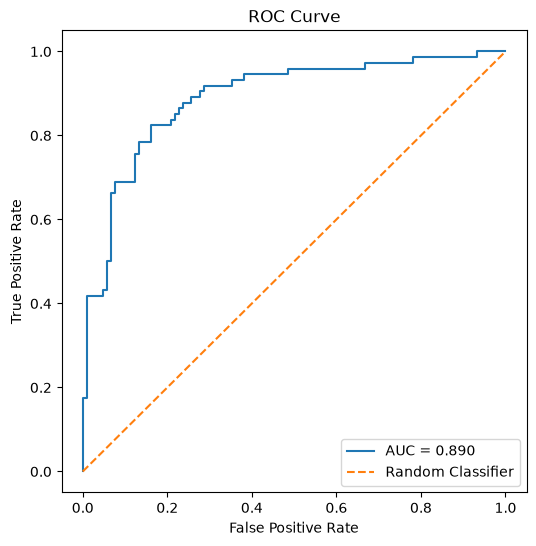

AUC Score: 0.8899613899613901


In [94]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability of the positive class
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

print("AUC Score:", auc)

In [95]:
print("Cabin in X:", "Cabin" in X.columns)
print("Cabin in X_train:", "Cabin" in X_train.columns)
print("Cabin in X_test:", "Cabin" in X_test.columns)

Cabin in X: False
Cabin in X_train: False
Cabin in X_test: False


# ROC Curve

**ROC (Receiver Operating Characteristic)** is a graphical representation of a binary classification model's performance across different probability thresholds.

It plots:

- **True Positive Rate (TPR)** on the Y-axis
- **False Positive Rate (FPR)** on the X-axis

A curve closer to the top-left corner indicates better model performance.

---

# AUROC

**AUROC (Area Under the Receiver Operating Characteristic Curve)** summarizes the ROC curve into a single value.

Interpretation:

- **1.0** → Perfect classifier
- **0.9–1.0** → Excellent
- **0.8–0.9** → Very Good
- **0.7–0.8** → Good
- **0.5** → Random guessing

Our Logistic Regression model achieved an **AUROC of 0.887**, indicating a very good ability to distinguish between survivors and non-survivors.

In [96]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
1,Sex,1.488682
12,Title_Master,1.369557
21,Deck_E,1.014378
15,Title_Mrs,0.916166
20,Deck_D,0.561286
6,CabinAvailable,0.253334
9,Embarked_C,0.250738
22,Deck_F,0.232790
5,Fare,0.217195
18,Deck_B,0.184143


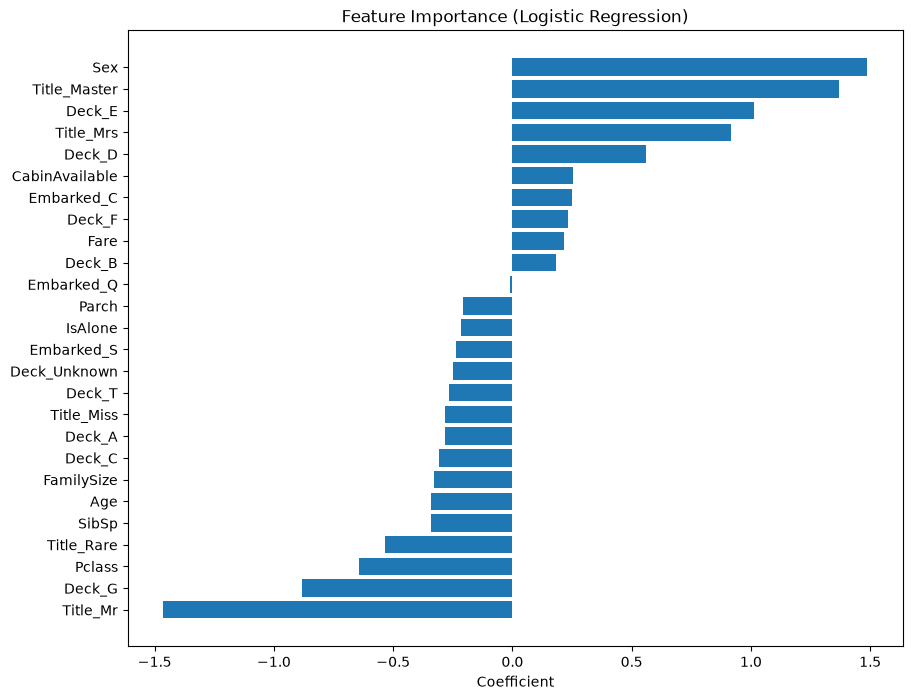

In [97]:
import matplotlib.pyplot as plt

coefficients = coefficients.sort_values("Coefficient")

plt.figure(figsize=(10,8))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient")
plt.show()

## Interpreting Logistic Regression Coefficients

The coefficient of a feature indicates how that feature influences the model's prediction while keeping all other features constant.

- Positive coefficient → Increases the predicted probability of the positive class (Survived = 1).
- Negative coefficient → Decreases the predicted probability of the positive class (Survived = 1), increasing the probability of the negative class (Survived = 0).

A coefficient does **not** represent the number of people who survived or died. Instead, it represents the direction and strength of the feature's influence on the model's prediction.

In [98]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

scores = cross_val_score(
    LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Scores:", scores)
print("Average Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Scores: [0.82122905 0.82022472 0.80337079 0.83146067 0.86516854]
Average Accuracy: 0.8282907538760906
Standard Deviation: 0.020522927676781884


## Decision Tree

In [99]:
from sklearn.model_selection import train_test_split

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [100]:
print(X_train_tree.dtypes)

Pclass              int64
Sex                 int64
Age               float64
SibSp               int64
Parch               int64
Fare              float64
CabinAvailable      int64
FamilySize          int64
IsAlone             int64
Embarked_C          int64
Embarked_Q          int64
Embarked_S          int64
Title_Master        int64
Title_Miss          int64
Title_Mr            int64
Title_Mrs           int64
Title_Rare          int64
Deck_A              int64
Deck_B              int64
Deck_C              int64
Deck_D              int64
Deck_E              int64
Deck_F              int64
Deck_G              int64
Deck_T              int64
Deck_Unknown        int64
dtype: object


In [101]:
print(X_train_tree.shape)
print(X_test_tree.shape)

(712, 26)
(179, 26)


In [102]:
from sklearn.tree import DecisionTreeClassifier
tree_model=DecisionTreeClassifier( random_state=42)
tree_model.fit(
    X_train_tree,
    y_train_tree
)
y_pred_tree = tree_model.predict(
    X_test_tree
)

In [103]:
from sklearn.metrics import accuracy_score

tree_accuracy = accuracy_score(
    y_test_tree,
    y_pred_tree
)

print(f"Decision Tree Accuracy: {tree_accuracy:.2%}")

Decision Tree Accuracy: 77.65%


In [104]:
tree_train_pred = tree_model.predict(X_train_tree)

tree_train_accuracy = accuracy_score(
    y_train_tree,
    tree_train_pred
)

print(f"Training Accuracy: {tree_train_accuracy:.2%}")

Training Accuracy: 98.74%


In [105]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = range(2, 11)

tree_results = []

for depth in depths:

    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train_tree, y_train_tree)

    train_pred = tree.predict(X_train_tree)
    test_pred = tree.predict(X_test_tree)

    train_accuracy = accuracy_score(
        y_train_tree,
        train_pred
    )

    test_accuracy = accuracy_score(
        y_test_tree,
        test_pred
    )

    tree_results.append({
        "Max Depth": depth,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy
    })

tree_results_df = pd.DataFrame(tree_results)

tree_results_df

,Max Depth,Training Accuracy,Testing Accuracy
0,2,0.794944,0.765363
1,3,0.827247,0.826816
2,4,0.846910,0.815642
3,5,0.869382,0.782123
4,6,0.886236,0.810056
5,7,0.907303,0.776536
6,8,0.918539,0.810056
7,9,0.933989,0.787709
8,10,0.945225,0.787709


In [106]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

depth_cv_results = []

for depth in range(2, 11):

    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    scores = cross_val_score(
        tree,
        X_train_tree,
        y_train_tree,
        cv=5,
        scoring="accuracy"
    )

    depth_cv_results.append({
        "Max Depth": depth,
        "CV Mean Accuracy": scores.mean(),
        "CV Std": scores.std()
    })

depth_cv_df = pd.DataFrame(depth_cv_results)

depth_cv_df

,Max Depth,CV Mean Accuracy,CV Std
0,2,0.795006,0.033891
1,3,0.810499,0.035172
2,4,0.807673,0.030048
3,5,0.806264,0.030055
4,6,0.800611,0.022904
5,7,0.802059,0.033947
6,8,0.795036,0.035611
7,9,0.793667,0.048648
8,10,0.796444,0.038480


In [107]:
best_depth = 3

In [108]:
best_depth = int(
    depth_cv_df.loc[
        depth_cv_df["CV Mean Accuracy"].idxmax(),
        "Max Depth"
    ]
)

print("Selected Max Depth:", best_depth)

Selected Max Depth: 3


In [109]:
tree_model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)
tree_model.fit(
    X_train_tree,
    y_train_tree
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [110]:
y_pred_tree = tree_model.predict(
    X_test_tree
)
tree_accuracy = accuracy_score(
    y_test_tree,
    y_pred_tree
)

print(f"Final Decision Tree Accuracy: {tree_accuracy:.2%}")

Final Decision Tree Accuracy: 82.68%


[[99 11]
 [20 49]]


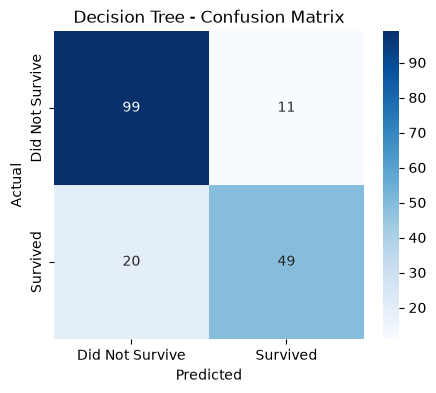

In [111]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_tree = confusion_matrix(
    y_test_tree,
    y_pred_tree
)

print(cm_tree)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")

plt.show()

In [112]:
y_prob_tree = tree_model.predict_proba(X_test_tree)[:, 1]

In [113]:
from sklearn.metrics import roc_curve, roc_auc_score

tree_auc = roc_auc_score(
    y_test_tree,
    y_prob_tree
)

print(f"Decision Tree AUROC: {tree_auc:.3f}")

Decision Tree AUROC: 0.849


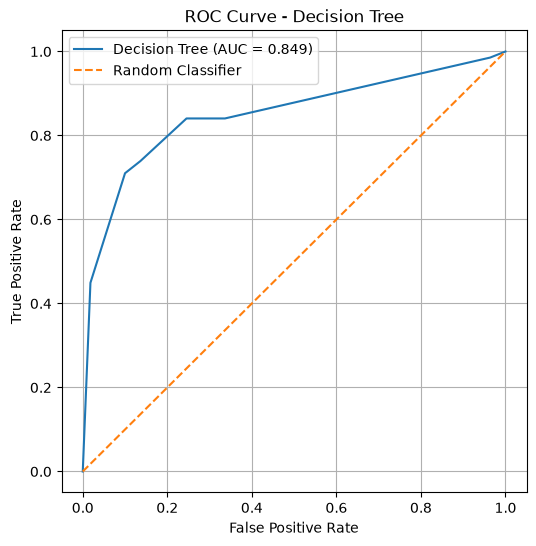

In [114]:
fpr_tree, tpr_tree, thresholds_tree = roc_curve(
    y_test_tree,
    y_prob_tree
)

plt.figure(figsize=(6, 6))

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {tree_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.grid()

plt.show()

## RANDOM FOREST

In [115]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [116]:
rf_model.fit(
    X_train_tree,
    y_train_tree
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [117]:
y_pred_rf = rf_model.predict(
    X_test_tree
)

In [118]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(
    y_test_tree,
    y_pred_rf
)

print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

Random Forest Accuracy: 78.77%


In [119]:
rf_train_pred = rf_model.predict(X_train_tree)

rf_train_accuracy = accuracy_score(
    y_train_tree,
    rf_train_pred
)

print(f"Random Forest Training Accuracy: {rf_train_accuracy:.2%}")
print(f"Random Forest Testing Accuracy: {rf_accuracy:.2%}")

Random Forest Training Accuracy: 98.74%
Random Forest Testing Accuracy: 78.77%


In [120]:
rf_depth_results = []

for depth in range(2, 11):

    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    rf.fit(X_train_tree, y_train_tree)

    train_pred = rf.predict(X_train_tree)
    test_pred = rf.predict(X_test_tree)

    train_accuracy = accuracy_score(
        y_train_tree,
        train_pred
    )

    test_accuracy = accuracy_score(
        y_test_tree,
        test_pred
    )

    rf_depth_results.append({
        "Max Depth": depth,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy
    })

rf_depth_df = pd.DataFrame(rf_depth_results)

rf_depth_df

,Max Depth,Training Accuracy,Testing Accuracy
0,2,0.808989,0.782123
1,3,0.832865,0.793296
2,4,0.842697,0.810056
3,5,0.858146,0.826816
4,6,0.877809,0.810056
5,7,0.904494,0.815642
6,8,0.926966,0.810056
7,9,0.933989,0.804469
8,10,0.953652,0.804469


In [121]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_cv_results = []

for depth in range(2, 11):

    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    scores = cross_val_score(
        rf,
        X_train_tree,
        y_train_tree,
        cv=5,
        scoring="accuracy"
    )

    rf_cv_results.append({
        "Max Depth": depth,
        "CV Mean Accuracy": scores.mean(),
        "CV Std": scores.std()
    })

rf_cv_df = pd.DataFrame(rf_cv_results)

rf_cv_df

,Max Depth,CV Mean Accuracy,CV Std
0,2,0.802009,0.021526
1,3,0.820260,0.020798
2,4,0.825884,0.013054
3,5,0.818832,0.014195
4,6,0.824476,0.015599
5,7,0.823097,0.019957
6,8,0.824485,0.015466
7,9,0.818871,0.019076
8,10,0.823106,0.025921


### Random Forest max_depth Tuning

The default Random Forest showed overfitting with 98.74% training accuracy but only 78.77% testing accuracy.

We tested different `max_depth` values to control the complexity of the individual trees.

The best testing accuracy in this experiment was achieved at `max_depth=5`, with:

- Training Accuracy: 85.81%
- Testing Accuracy: 82.68%

Limiting tree depth reduced overfitting and improved generalization.

In [122]:
best_rf_depth = int(
    rf_cv_df.loc[
        rf_cv_df["CV Mean Accuracy"].idxmax(),
        "Max Depth"
    ]
)

print("Best Random Forest Depth:", best_rf_depth)

Best Random Forest Depth: 4


In [123]:
print(rf_depth_df.columns)

Index(['Max Depth', 'Training Accuracy', 'Testing Accuracy'], dtype='str')


In [124]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

In [125]:
rf_model.fit(
    X_train_tree,
    y_train_tree
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [126]:
rf_pred=rf_model.predict(
    X_test_tree
)

In [127]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(
    y_test_tree,
    y_pred_rf
)

print(f"Final Random Forest Accuracy: {rf_accuracy:.2%}")

Final Random Forest Accuracy: 78.77%


In [128]:
rf_train_pred = rf_model.predict(X_train_tree)

rf_train_accuracy = accuracy_score(
    y_train_tree,
    rf_train_pred
)

print(f"Random Forest Training Accuracy: {rf_train_accuracy:.2%}")
print(f"Random Forest Testing Accuracy: {rf_accuracy:.2%}")

Random Forest Training Accuracy: 84.27%
Random Forest Testing Accuracy: 78.77%


In [129]:
RandomForestClassifier(
    n_estimators=100,
    max_depth=4
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [130]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

max_features_results = []

for feature_option in ["sqrt", "log2", None]:

    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=4,
        max_features=feature_option,
        random_state=42
    )

    scores = cross_val_score(
        rf,
        X_train_tree,
        y_train_tree,
        cv=5,
        scoring="accuracy"
    )

    max_features_results.append({
        "Max Features": str(feature_option),
        "CV Mean Accuracy": scores.mean(),
        "CV Std": scores.std()
    })

max_features_df = pd.DataFrame(max_features_results)

max_features_df

,Max Features,CV Mean Accuracy,CV Std
0,sqrt,0.825884,0.013054
1,log2,0.823087,0.019573
2,None,0.818901,0.028358


In [131]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

leaf_results = []

for leaf in [1, 2, 4, 5, 10]:

    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=4,
        max_features="sqrt",
        min_samples_leaf=leaf,
        random_state=42
    )

    scores = cross_val_score(
        rf,
        X_train_tree,
        y_train_tree,
        cv=5,
        scoring="accuracy"
    )

    leaf_results.append({
        "Min Samples Leaf": leaf,
        "CV Mean Accuracy": scores.mean(),
        "CV Std": scores.std()
    })

leaf_df = pd.DataFrame(leaf_results)

leaf_df

,Min Samples Leaf,CV Mean Accuracy,CV Std
0,1,0.825884,0.013054
1,2,0.823077,0.013011
2,4,0.830109,0.017450
3,5,0.830109,0.017450
4,10,0.824485,0.020878


In [132]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

tree_number_results = []

for n_trees in [50, 100, 200, 300, 500]:

    rf = RandomForestClassifier(
        n_estimators=n_trees,
        max_depth=4,
        max_features="sqrt",
        min_samples_leaf=4,
        random_state=42
    )

    scores = cross_val_score(
        rf,
        X_train_tree,
        y_train_tree,
        cv=5,
        scoring="accuracy"
    )

    tree_number_results.append({
        "Number of Trees": n_trees,
        "CV Mean Accuracy": scores.mean(),
        "CV Std": scores.std()
    })

tree_number_df = pd.DataFrame(tree_number_results)

tree_number_df

,Number of Trees,CV Mean Accuracy,CV Std
0,50,0.831518,0.019350
1,100,0.830109,0.017450
2,200,0.830099,0.015788
3,300,0.831508,0.015487
4,500,0.832916,0.015694


In [133]:
rf_final = RandomForestClassifier(
    n_estimators=500,
    max_depth=4,
    max_features="sqrt",
    min_samples_leaf=4,
    random_state=42
)

rf_final.fit(
    X_train_tree,
    y_train_tree
)

y_pred_rf_final = rf_final.predict(
    X_test_tree
)

In [134]:
from sklearn.metrics import accuracy_score

rf_final_accuracy = accuracy_score(
    y_test_tree,
    y_pred_rf_final
)

print(f"Final Random Forest Accuracy: {rf_final_accuracy:.2%}")

Final Random Forest Accuracy: 80.45%


In [135]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train_tree.columns,
    "Importance": rf_final.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
14,Title_Mr,0.239428
1,Sex,0.235517
5,Fare,0.073694
6,CabinAvailable,0.065966
0,Pclass,0.065317
13,Title_Miss,0.053837
15,Title_Mrs,0.050277
25,Deck_Unknown,0.045514
2,Age,0.039596
7,FamilySize,0.038942


## Feature engineering needed one more timee

In [136]:
df_engineered = df_processed.copy()

In [137]:
print("Shape:", df_engineered.shape)

print("\nColumns:")
print(df_engineered.columns.tolist())

Shape: (891, 28)

Columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'CabinAvailable', 'FamilySize', 'IsAlone', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown']


In [138]:
print("\nData Types:")
print(df_engineered.dtypes)


Data Types:
Survived            int64
Pclass              int64
Sex                 int64
Age               float64
SibSp               int64
Parch               int64
Fare              float64
Cabin                 str
CabinAvailable      int64
FamilySize          int64
IsAlone             int64
Embarked_C          int64
Embarked_Q          int64
Embarked_S          int64
Title_Master        int64
Title_Miss          int64
Title_Mr            int64
Title_Mrs           int64
Title_Rare          int64
Deck_A              int64
Deck_B              int64
Deck_C              int64
Deck_D              int64
Deck_E              int64
Deck_F              int64
Deck_G              int64
Deck_T              int64
Deck_Unknown        int64
dtype: object


In [139]:
df_engineered.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,CabinAvailable,FamilySize,...,Title_Rare,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,0,3,0,22.0,1,0,7.2500,NaN,0,2,...,0,0,0,0,0,0,0,0,0,1
1,1,1,1,38.0,1,0,71.2833,C85,1,2,...,0,0,0,1,0,0,0,0,0,0
2,1,3,1,26.0,0,0,7.9250,NaN,0,1,...,0,0,0,0,0,0,0,0,0,1
3,1,1,1,35.0,1,0,53.1000,C123,1,2,...,0,0,0,1,0,0,0,0,0,0
4,0,3,0,35.0,0,0,8.0500,NaN,0,1,...,0,0,0,0,0,0,0,0,0,1


In [140]:
df_engineered = df_engineered.drop("Cabin", axis=1)

In [141]:
print(df_engineered.columns.tolist())
print(df_engineered.dtypes)

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'CabinAvailable', 'FamilySize', 'IsAlone', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown']
Survived            int64
Pclass              int64
Sex                 int64
Age               float64
SibSp               int64
Parch               int64
Fare              float64
CabinAvailable      int64
FamilySize          int64
IsAlone             int64
Embarked_C          int64
Embarked_Q          int64
Embarked_S          int64
Title_Master        int64
Title_Miss          int64
Title_Mr            int64
Title_Mrs           int64
Title_Rare          int64
Deck_A              int64
Deck_B              int64
Deck_C              int64
Deck_D              int64
Deck_E              int64
Deck_F              int64
Deck_G              int64
Deck_T              int64
Deck_Unknow

In [175]:
df_engineered["IsChild"] = (
    df_engineered["Age"] < 18
).astype(int)

In [185]:
def family_category(size):
    if size == 1:
        return 0       # Alone
    elif size <= 4:
        return 1       # Small
    elif size <= 6:
        return 2       # Medium
    else:
        return 3       # Large

df_engineered["FamilySizeCategory"] = (
    df_engineered["FamilySize"]
    .apply(family_category)
)

In [186]:
print(df_engineered.shape)
print(df_engineered.columns.tolist())

(891, 29)
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'CabinAvailable', 'FamilySize', 'IsAlone', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown', 'IsChild', 'FamilySizeCategory']


In [187]:
X_engineered = df_engineered.drop("Survived", axis=1)
y_engineered = df_engineered["Survived"]

In [188]:
from sklearn.model_selection import train_test_split

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered,
    y_engineered,
    test_size=0.2,
    random_state=42,
    stratify=y_engineered
)

print("Training shape:", X_train_eng.shape)
print("Testing shape:", X_test_eng.shape)

Training shape: (712, 28)
Testing shape: (179, 28)


In [189]:
from sklearn.ensemble import RandomForestClassifier

rf_engineered = RandomForestClassifier(
    n_estimators=500,
    max_depth=4,
    max_features="sqrt",
    min_samples_leaf=4,
    random_state=42
)

rf_engineered.fit(
    X_train_eng,
    y_train_eng
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [190]:
y_pred_eng = rf_engineered.predict(X_test_eng)

In [191]:
from sklearn.metrics import accuracy_score

eng_accuracy = accuracy_score(
    y_test_eng,
    y_pred_eng
)

print(f"Random Forest Accuracy with New Features: {eng_accuracy:.2%}")

Random Forest Accuracy with New Features: 81.01%


In [192]:
feature_importance_eng = pd.DataFrame({
    "Feature": X_train_eng.columns,
    "Importance": rf_engineered.feature_importances_
})

feature_importance_eng = feature_importance_eng.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_eng.head(20)

,Feature,Importance
14,Title_Mr,0.237102
1,Sex,0.210891
5,Fare,0.071180
0,Pclass,0.060815
13,Title_Miss,0.059451
15,Title_Mrs,0.057637
6,CabinAvailable,0.056414
25,Deck_Unknown,0.056042
2,Age,0.038462
7,FamilySize,0.034504
